### Piotr Przymus 127902
# Klasteryzacja danych w Pythonie

#### 1) Importy i ustawienia

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)
plt.rcParams.update({'figure.max_open_warning': 0})

#### 2) Funkcje pomocnicze

In [4]:
def load_data(use_csv: bool = False, csv_path: str = 'dane.csv', dataset: str = 'blobs') -> np.ndarray:
    if use_csv:
        df = pd.read_csv(csv_path)
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) < 2:
            raise ValueError('Plik CSV musi zawierać co najmniej dwie kolumny numeryczne')
        return df[num_cols[:2]].to_numpy()
    if dataset == 'moons':
        X, _ = make_moons(n_samples=500, noise=0.08, random_state=42)
        return X
    X, _ = make_blobs(n_samples=600, centers=4, cluster_std=1.2, random_state=42)
    return X

def standardize(X: np.ndarray) -> np.ndarray:
    scaler = StandardScaler()
    return scaler.fit_transform(X)

def evaluate_kmeans(X_scaled: np.ndarray, k_min: int = 2, k_max: int = 10):
    results = []
    best_k = None
    best_sil = -1.0
    for k in range(k_min, k_max + 1):
        model = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        dbi = davies_bouldin_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        results.append({
            'K': k,
            'silhouette': sil,
            'davies_bouldin': dbi,
            'calinski_harabasz': ch,
            'model': model,
            'labels': labels,
        })
        if sil > best_sil:
            best_sil = sil
            best_k = k
    return results, best_k

def plot_metrics(results):
    ks = [r['K'] for r in results]
    sils = [r['silhouette'] for r in results]
    dbis = [r['davies_bouldin'] for r in results]
    chs = [r['calinski_harabasz'] for r in results]
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(ks, sils, marker='o')
    plt.title('Silhouette vs K')
    plt.xlabel('K')
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 3, 2)
    plt.plot(ks, dbis, marker='o')
    plt.title('Davies-Bouldin vs K')
    plt.xlabel('K')
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 3, 3)
    plt.plot(ks, chs, marker='o')
    plt.title('Calinski-Harabasz vs K')
    plt.xlabel('K')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_clusters_2d(X_scaled, labels, centroids=None, title='K-Means klasteryzacja'):
    plt.figure(figsize=(6, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=30)
    if centroids is not None:
        plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='k')
    plt.title(title)
    plt.xlabel('Cecha 1 (standaryzowana)')
    plt.ylabel('Cecha 2 (standaryzowana)')
    plt.show()

def plot_silhouette_diagram(X_scaled, labels, k, sil_avg, cmap_name='tab10'):
    """Rysuje wykres silhouette z kolorami odpowiadającymi klastrom z tej samej mapy kolorów."""
    sil_values = silhouette_samples(X_scaled, labels)
    plt.figure(figsize=(7, 5))
    y_lower = 10
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(k)]
    for cluster_id in range(k):
        vals = sil_values[labels == cluster_id]
        vals.sort()
        size = vals.shape[0]
        y_upper = y_lower + size
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.8, color=colors[cluster_id])
        plt.text(-0.05, y_lower + 0.5 * size, str(cluster_id))
        y_lower = y_upper + 10
    plt.axvline(sil_avg, linestyle='--')
    plt.title(f'Wykres Silhouette dla K={k} (średnia={sil_avg:.3f})')
    plt.xlabel('Wartość silhouette s(i)')
    plt.yticks([])
    plt.show()

def compare_kmeans_dbscan_on_moons():
    X = load_data(use_csv=False, dataset='moons')
    Xs = standardize(X)
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    k_labels = kmeans.fit_predict(Xs)
    k_sil = silhouette_score(Xs, k_labels)
    db = DBSCAN(eps=0.25, min_samples=5)
    db_labels = db.fit_predict(Xs)
    valid_mask = db_labels != -1
    db_sil = None
    if len(set(db_labels[valid_mask])) >= 2:
        try:
            db_sil = silhouette_score(Xs[valid_mask], db_labels[valid_mask])
        except Exception:
            db_sil = None
    print(f'K-Means (K=2) Silhouette={k_sil:.3f}')
    if db_sil is not None:
        print(f'DBSCAN Silhouette ={db_sil:.3f}')
    else:
        print('DBSCAN: zbyt mało klastrów do obliczenia miar')
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(Xs)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title('K-Means (K=2) na make_moons')
    plt.scatter(X2[:, 0], X2[:, 1], c=k_labels, cmap='tab10', s=30)
    plt.subplot(1, 2, 2)
    plt.title('DBSCAN na make_moons')
    plt.scatter(X2[:, 0], X2[:, 1], c=db_labels, cmap='tab10', s=30)
    plt.tight_layout()
    plt.show()

#### 3) Generowanie danych (make_blobs) i standaryzacja

In [5]:
X = load_data(use_csv=False, dataset='blobs')
X_scaled = standardize(X)
print('Kształt danych:', X.shape)

Kształt danych: (600, 2)


#### 4) Ewaluacja K-Means dla K=2..10

Wyniki dla różnych K:
K=2 | Silhouette=0.544 | DBI=0.602 | CH=525.9
K=3 | Silhouette=0.720 | DBI=0.393 | CH=1985.8
K=4 | Silhouette=0.753 | DBI=0.346 | CH=4486.0
K=5 | Silhouette=0.642 | DBI=0.647 | CH=3736.7
K=6 | Silhouette=0.512 | DBI=0.896 | CH=3333.8
K=7 | Silhouette=0.412 | DBI=1.046 | CH=3137.0
K=8 | Silhouette=0.322 | DBI=1.183 | CH=2977.4
K=9 | Silhouette=0.334 | DBI=1.073 | CH=2930.7
K=10 | Silhouette=0.347 | DBI=1.010 | CH=2858.9

Najlepsze K wg silhouette: 4


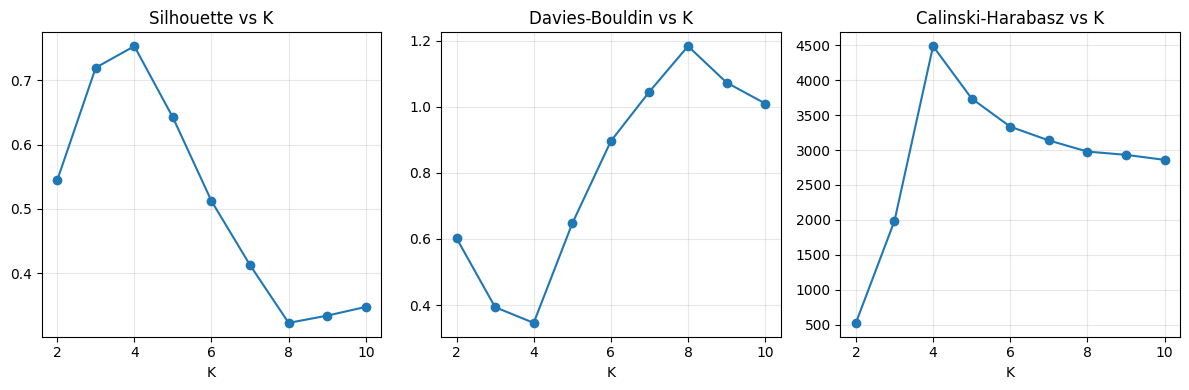

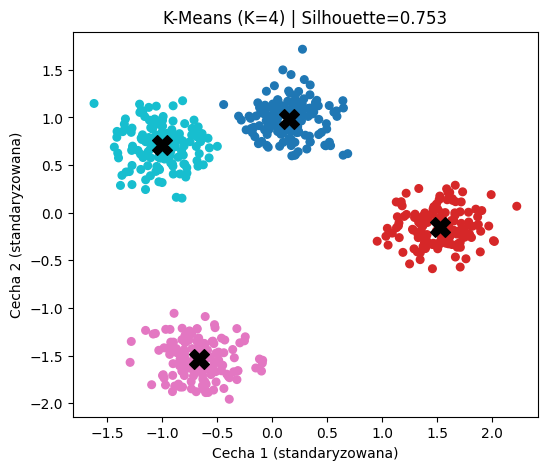

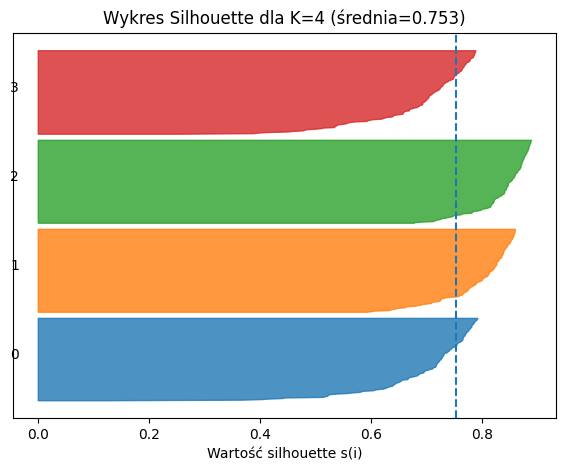

In [6]:
results, best_k = evaluate_kmeans(X_scaled, k_min=2, k_max=10)
print('Wyniki dla różnych K:')
for r in results:
    print(f"K={r['K']} | Silhouette={r['silhouette']:.3f} | DBI={r['davies_bouldin']:.3f} | CH={r['calinski_harabasz']:.1f}")
print(f"\nNajlepsze K wg silhouette: {best_k}")

plot_metrics(results)
best = next(r for r in results if r['K'] == best_k)
plot_clusters_2d(X_scaled, best['labels'], best['model'].cluster_centers_, title=f'K-Means (K={best_k}) | Silhouette={best['silhouette']:.3f}')
plot_silhouette_diagram(X_scaled, best['labels'], best_k, best['silhouette'], cmap_name='tab10')

#### 5) Interpretacja wyników

Na podstawie wyników najlepsze K to 4 (najwyższy średni Silhouette = 0.753).

Dla K=4 Davies–Bouldin jest najniższy (0.346), a Calinski–Harabasz najwyższy (≈4486) - klastry wykazują się największą separacją i największą spójnością.

Dla K>4 wartość Silhouette i Calinski–Harabasz spada, a Davies–Bouldin rośnie, co sugeruje, że klastrów jest zbyt dużo.

K=3 także daje dobre wyniki (Silhouette=0.720), ale jednak metryki wskazują K=4 jako najlepszy wybór dla tych danych.

#### 6) Rozszerzenie: porównanie z DBSCAN na `make_moons`

K-Means (K=2) Silhouette=0.493
DBSCAN Silhouette =0.384


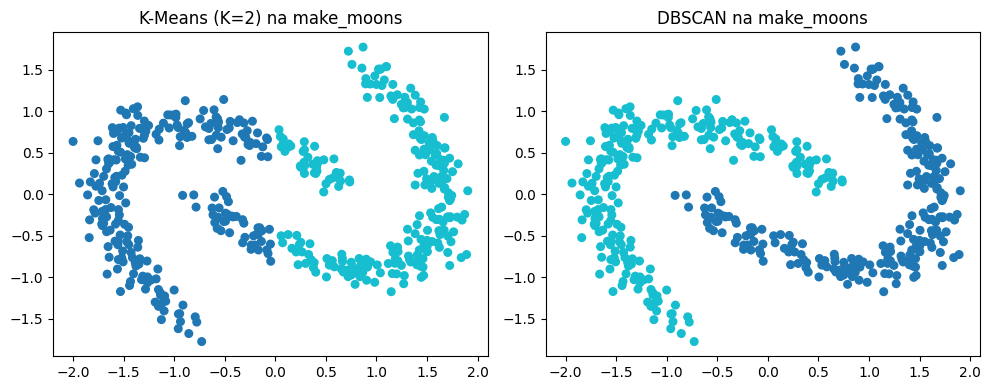

In [7]:
compare_kmeans_dbscan_on_moons()

DBSCAN lepiej odwzorowuje nieliniowy kształt danych `make_moons` - grupuje dwa półksiężyce naturalnie.
K‑Means z K=2 działa OK jako proste przybliżenie, ale wymaga liniowego podziału przestrzeni, dlatego dla tego typu danych DBSCAN jest zwykle lepszym wyborem.